# Beam optimization environments: design choices and formulas

This notebook documents the actual configuration shared by `TraceWinEnv` and `SurrogateEnv`: observations, sensitivity, scale calibration, reset noise, actions, trajectory limits, score, reward, and episode termination. All numerical values are read from the current Python configuration.

> This notebook is read-only: it does not run TraceWin and does not change the environment configuration.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'beam_optimization').is_dir():
    REPO_ROOT = WORKING_DIR
else:
    PROJECT_ROOT = WORKING_DIR
    while PROJECT_ROOT.name != 'beam_optimization' and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent
    REPO_ROOT = PROJECT_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_optimization.config.adige import (
    ACTION_SCALE, BAYESIAN_SCALE, BEAM_STATE_DIM, BEAM_STATE_FEATURES,
    DATASET_SCALE, ERROR_SCORE, EXPLORATION_SCALE, FAILURE_PENALTY,
    MAX_STEPS, OBSERVATION_STAGE_MASK, PARAMETERS, RESET_SCALE,
    SCORE_REFERENCES, SCORE_WEIGHTS, STAGE_MARKERS, action_bounds,
    dataset_std_vec, observation_dim, observation_stage_indices,
    observation_stage_labels, reset_std_vec, sensitivity_vec,
)
from beam_optimization.config.offline_utility.scales_calculation import (
    DEFAULT_F_RESET, DEFAULT_K_SIGMA, DEFAULT_K_SIGMA_DATASET,
    verify_constraints,
)

def fmt(value):
    return f'{float(value):.6g}'

def fmt_bound(value):
    return 'unbounded' if value is None else fmt(value)

def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(str(cell) for cell in row) + ' |' for row in rows)
    return '\n'.join(lines)


## 1. Observation space

### 1.1 The Gymnasium space contract

A Gymnasium environment must define two complementary `Space` objects:

- `observation_space`: **what the agent can see**;
- `action_space`: **what the agent is allowed to do**.

A `Space` provides, among other operations, `contains(x)` to test whether a value belongs to the declared space and `sample()` to generate a valid sample. Gymnasium offers several space types; this environment uses continuous `Box` spaces because both beam features and machine corrections are real-valued vectors.

### 1.2 What the policy observes

`TraceWinEnv` and `SurrogateEnv` expose the same observation: selected beam states produced by their respective simulator backends. Each selected longitudinal stage contributes the nine configured beam features. The controlled parameter values, previous action, reward, and score are **not** appended to the observation.

### 1.3 Observation `Box`: construction and dimension

If $s_1,\ldots,s_m$ are the stages enabled by `OBSERVATION_STAGE_MASK`, their beam-state rows are concatenated in beam-line order and flattened:

$$o_t = \operatorname{flatten}\left(B_t[s_1],\ldots,B_t[s_m]\right), \qquad \dim(o_t)=m\times BEAM\_STATE\_DIM.$$

The declared Gymnasium space is

$$\mathcal{O}=\operatorname{Box}\left(low=-\infty,high=+\infty,shape=(m\times BEAM\_STATE\_DIM,),dtype=float32\right).$$

The resulting fixed-length `float32` vector is the input to the policy. The dynamic tables below show the exact active stages, feature order, observation dimension, and action dimension from the current configuration.

### 1.4 Design reasoning and consequences

Using the same observation definition for both backends allows one policy interface to operate with either TraceWin or the surrogate. The input stage describes the incoming beam, intermediate visible stages provide longitudinal context, and the final stage describes the resulting beam quality. Selecting only configured stages limits the neural-network input size.

Because score and machine parameters are excluded, the policy must choose corrections from the beam state itself. The score remains available separately as `info["score"]` for reporting, while reward supplies the learning signal. This is an important modeling choice rather than a clipping or safety mechanism.


In [2]:
visible_indices = observation_stage_indices()
visible_labels = observation_stage_labels()
action_low, action_high = action_bounds()

stage_rows = []
for index, (marker, visible) in enumerate(zip(STAGE_MARKERS, OBSERVATION_STAGE_MASK)):
    label = 'beam0' if index == 0 else ('final' if index == len(STAGE_MARKERS) - 1 else f'marker_{marker}')
    stage_rows.append([index, marker, f'`{label}`', 'yes' if visible else 'no'])

meanings = {
    'npart_ratio': 'surviving particle fraction',
    'x0': 'horizontal centroid [mm]', 'y0': 'vertical centroid [mm]',
    'SizeX': 'horizontal RMS size [mm]', 'SizeY': 'vertical RMS size [mm]',
    'ex': 'horizontal geometric RMS emittance [mm.mrad]',
    'ey': 'vertical geometric RMS emittance [mm.mrad]',
    "x'0": 'horizontal angular centroid [mrad]',
    "y'0": 'vertical angular centroid [mrad]',
}
feature_rows = [[i, f'`{name}`', meanings[name], 'yes'] for i, name in enumerate(BEAM_STATE_FEATURES)]
interface_rows = [[
    name, f'{len(visible_indices)} × {BEAM_STATE_DIM} = {observation_dim()}',
    str((observation_dim(),)), str(action_low.shape), '`info["score"]`',
] for name in ('TraceWinEnv', 'SurrogateEnv')]

display(Markdown('\n\n'.join([
    table(['Environment', 'Observation formula', 'Obs shape', 'Action shape', 'Score output'], interface_rows),
    '### 1.5 Beam stages and visibility',
    table(['Stage index', 'TraceWin marker', 'Label', 'Visible to the agent'], stage_rows),
    f'Current observation: **{", ".join(visible_labels)}**, therefore **{observation_dim()} float32 values**.',
    '### 1.6 Features in each visible stage',
    table(['Index', 'Feature', 'Meaning', 'Used by score'], feature_rows),
])))


| Environment | Observation formula | Obs shape | Action shape | Score output |
| --- | --- | --- | --- | --- |
| TraceWinEnv | 3 × 9 = 27 | (27,) | (18,) | `info["score"]` |
| SurrogateEnv | 3 × 9 = 27 | (27,) | (18,) | `info["score"]` |

### 1.5 Beam stages and visibility

| Stage index | TraceWin marker | Label | Visible to the agent |
| --- | --- | --- | --- |
| 0 | 0 | `beam0` | yes |
| 1 | 2 | `marker_2` | no |
| 2 | 29 | `marker_29` | no |
| 3 | 38 | `marker_38` | no |
| 4 | 151 | `marker_151` | no |
| 5 | 162 | `marker_162` | yes |
| 6 | 195 | `marker_195` | no |
| 7 | 197 | `marker_197` | no |
| 8 | 203 | `marker_203` | no |
| 9 | 205 | `marker_205` | no |
| 10 | 225 | `marker_225` | no |
| 11 | 261 | `marker_261` | no |
| 12 | 280 | `final` | yes |

Current observation: **beam0, marker_162, final**, therefore **27 float32 values**.

### 1.6 Features in each visible stage

| Index | Feature | Meaning | Used by score |
| --- | --- | --- | --- |
| 0 | `npart_ratio` | surviving particle fraction | yes |
| 1 | `x0` | horizontal centroid [mm] | yes |
| 2 | `y0` | vertical centroid [mm] | yes |
| 3 | `SizeX` | horizontal RMS size [mm] | yes |
| 4 | `SizeY` | vertical RMS size [mm] | yes |
| 5 | `ex` | horizontal geometric RMS emittance [mm.mrad] | yes |
| 6 | `ey` | vertical geometric RMS emittance [mm.mrad] | yes |
| 7 | `x'0` | horizontal angular centroid [mrad] | yes |
| 8 | `y'0` | vertical angular centroid [mrad] | yes |

## 2. Action space and sensitivity-based bounds

The observation space specifies **what the policy receives**. The action space instead specifies **what the policy may change**.

### 2.1 Defining what the agent is allowed to do

Every controlled TraceWin parameter is continuous, so a `Discrete` space would be inappropriate. The environment therefore needs a continuous Gymnasium `Box` with one component for each parameter:

$$\mathcal{A}=\operatorname{Box}\left(low=\mathbf{a}^{min},high=\mathbf{a}^{max},dtype=float32\right),\qquad shape(\mathcal{A})=(N\_PARAMS,).$$

Currently `N_PARAMS = 18`, and component $p$ is the requested physical delta for parameter $p$ in `PARAMETERS` order. `action_space.contains(a)` checks the vector shape, dtype compatibility, and bounds. `action_space.sample()` draws a random valid vector from the bounded box; this is useful for checks or explicitly random exploration, but it is not how a trained policy normally chooses its action.

Declaring `Box` and its shape is not sufficient: the vectors $\mathbf{a}^{min}$ and $\mathbf{a}^{max}$ must also be physically meaningful. A single absolute limit cannot be shared directly because the 18 parameters have different units and magnitudes. This motivates the sensitivity calibration below.

### 2.2 Why sensitivity is introduced

The 18 controlled parameters have different units and numerical magnitudes, so one common absolute action bound would not represent a comparable physical effect. A parameter-specific calibration is needed before the action bounds can be defined.

For parameter $p$, `sensitivity_p` is the physical interval estimated to produce an absolute score change of approximately one point near its calibration point:

$$s_p \approx \frac{\Delta p}{|\Delta score|}.$$

Sensitivity is a **local calibration unit**. It is not a hardware limit and does not guarantee linear behavior far from the calibration point. Multiplying $s_p$ by one shared dimensionless scale produces a different physical width for each parameter while targeting a comparable local effect.

### 2.3 From sensitivity to physical widths

$$\sigma_{dataset,p}=DATASET\_SCALE\,s_p$$
$$\sigma_{reset,p}=RESET\_SCALE\,s_p$$
$$a_{max,p}=ACTION\_SCALE\,s_p$$
$$trajectory_{max,p}=MAX\_STEPS\,a_{max,p}.$$

`EXPLORATION_SCALE` calibrates both dataset sampling and the default Bayesian search width. The 25%/75% allocation then derives reset and full-trajectory widths from that common trust region. Only after these sensitivity-based widths are calculated are hardware bounds applied as separate clipping limits.


### 2.4 Current global scales

| Quantity | Symbol | Formula | Value | Physical meaning |
| --- | --- | --- | --- | --- |
| Exploration scale | `EXPLORATION_SCALE` | largest tested scale with ≥90% successful TraceWin simulations for both dataset Gaussian and Bayesian Sobol samples | 0.35 | shared exploration width; `success=True`, therefore runs with `All particles are lost` are excluded from the successful fraction |
| Dataset Gaussian width | `DATASET_SCALE` | `DATASET_SCALE = EXPLORATION_SCALE` | 0.35 | `dataset_std_p = DATASET_SCALE × sensitivity_p` |
| Bayesian half-width | `BAYESIAN_SCALE` | `BAYESIAN_SCALE = EXPLORATION_SCALE` | 0.35 | default ± Bayesian interval |
| Reset Gaussian width | `RESET_SCALE` | `f_reset × k_sigma_dataset × DATASET_SCALE / k_sigma` | 0.0875 | `reset_std_p = RESET_SCALE × sensitivity_p` |
| Per-step action half-width | `ACTION_SCALE` | `(1 − f_reset) × k_sigma_dataset × DATASET_SCALE / MAX_STEPS` | 0.039375 | `step_max_p = ACTION_SCALE × sensitivity_p` |
| Episode horizon | `MAX_STEPS` | configured episode length | 20 | maximum number of actions |

### 2.5 Full 25% / 75% trust-region allocation

Values used in the budget equation:

| Variable | Value | Meaning |
| --- | --- | --- |
| `k_sigma` | 3 | reset excursion measured in reset standard deviations |
| `RESET_SCALE` | 0.0875 | Gaussian reset width in sensitivity units |
| `MAX_STEPS` | 20 | number of actions in a full trajectory |
| `ACTION_SCALE` | 0.039375 | maximum per-step action in sensitivity units |
| `k_sigma_dataset` | 3 | dataset trust-region radius in dataset standard deviations |
| `DATASET_SCALE` | 0.35 | dataset standard deviation in sensitivity units |
| `f_reset` | 0.25 | fraction of the trust-region radius assigned to reset |

Budget identities (all distances are expressed in units of parameter sensitivity):

```text
Trust region = k_sigma_dataset × DATASET_SCALE × sensitivity = 3 × 0.35 × sensitivity = 1.05 × sensitivity

Reset = k_sigma × RESET_SCALE × sensitivity = 3 × 0.0875 × sensitivity = 0.2625 × sensitivity (25% of trust region)

Full trajectory = MAX_STEPS × ACTION_SCALE × sensitivity = 20 × 0.039375 × sensitivity = 0.7875 × sensitivity (75% of trust region)

Reset + full trajectory = 0.2625 × sensitivity + 0.7875 × sensitivity = 1.05 × sensitivity = Trust region
```

### 2.6 Per-parameter physical intervals

All intervals come from the sensitivity in the same row. `Trajectory max` is action-only; hardware clipping may reduce the reachable displacement.

| # | Parameter | Default | Sensitivity | HW min | HW max | Dataset std | Reset std | Action/step | Trajectory max |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | `AD.SO.01` | 0.430916 | 0.00554938 | 0.347537 | 0.451941 | 0.00194228 | 0.000485571 | ±0.000218507 | ±0.00437013 |
| 1 | `AD.SO.02` | 0.118277 | 0.00593636 | -0.297224 | 0.32856 | 0.00207772 | 0.000519431 | ±0.000233744 | ±0.00467488 |
| 2 | `AD.MS.03.X` | -0.000126626 | 2.0956e-05 | -293.658 | 82.589 | 7.33459e-06 | 1.83365e-06 | ±8.25142e-07 | ±1.65028e-05 |
| 3 | `AD.MS.03.Y` | -3.09583e-05 | 2.30689e-05 | -0.000505167 | 0.001 | 8.0741e-06 | 2.01852e-06 | ±9.08336e-07 | ±1.81667e-05 |
| 4 | `AD.1EQ.01` | 132.587 | 40.3387 | -2.90181e+09 | 2.90183e+09 | 14.1186 | 3.52964 | ±1.58834 | ±31.7667 |
| 5 | `AD.MS.04.X` | -4.98577e-07 | 2.7343e-05 | -0.78351 | 0.00121984 | 9.57003e-06 | 2.39251e-06 | ±1.07663e-06 | ±2.15326e-05 |
| 6 | `AD.MS.04.Y` | 3.9278e-05 | 2.78537e-05 | -4.51339 | 0.00552153 | 9.7488e-06 | 2.4372e-06 | ±1.09674e-06 | ±2.19348e-05 |
| 7 | `AD.1EQ.02` | -8.33175 | 53.1789 | -207782 | 2.33489e+07 | 18.6126 | 4.65315 | ±2.09392 | ±41.8784 |
| 8 | `AD.D.02` | -0.0462107 | 6.71601e-05 | -0.214648 | -0.000426794 | 2.3506e-05 | 5.87651e-06 | ±2.64443e-06 | ±5.28886e-05 |
| 9 | `AD.EM.6` | 160.759 | 199.512 | unbounded | unbounded | 69.8291 | 17.4573 | ±7.85578 | ±157.116 |
| 10 | `AD.EM.8` | 0.156565 | 1403.56 | unbounded | unbounded | 491.246 | 122.811 | ±55.2652 | ±1105.3 |
| 11 | `AD.EM.10` | 0.00610927 | 17527.4 | unbounded | unbounded | 6134.58 | 1533.64 | ±690.14 | ±13802.8 |
| 12 | `AD.EM.12` | 24.3 | 76410.2 | unbounded | unbounded | 26743.6 | 6685.9 | ±3008.65 | ±60173.1 |
| 13 | `AD.D.03` | 0.0462113 | 1.34929e-05 | -0.214648 | 0.127347 | 4.72252e-06 | 1.18063e-06 | ±5.31283e-07 | ±1.06257e-05 |
| 14 | `AD.1EQ.03` | 14.4101 | 26.2319 | -3.21944e+08 | 2.75961e+08 | 9.18118 | 2.29529 | ±1.03288 | ±20.6576 |
| 15 | `AD.MS.05.X` | 0.000104377 | 0.000114677 | -0.001 | 0.001 | 4.0137e-05 | 1.00343e-05 | ±4.51542e-06 | ±9.03083e-05 |
| 16 | `AD.MS.05.Y` | -7.68117e-05 | 2.33105e-05 | -0.001 | 0.001 | 8.15867e-06 | 2.03967e-06 | ±9.17851e-07 | ±1.8357e-05 |
| 17 | `AD.1EQ.04` | -165.187 | 36.6283 | -3.659e+08 | 3.65916e+08 | 12.8199 | 3.20498 | ±1.44224 | ±28.8448 |

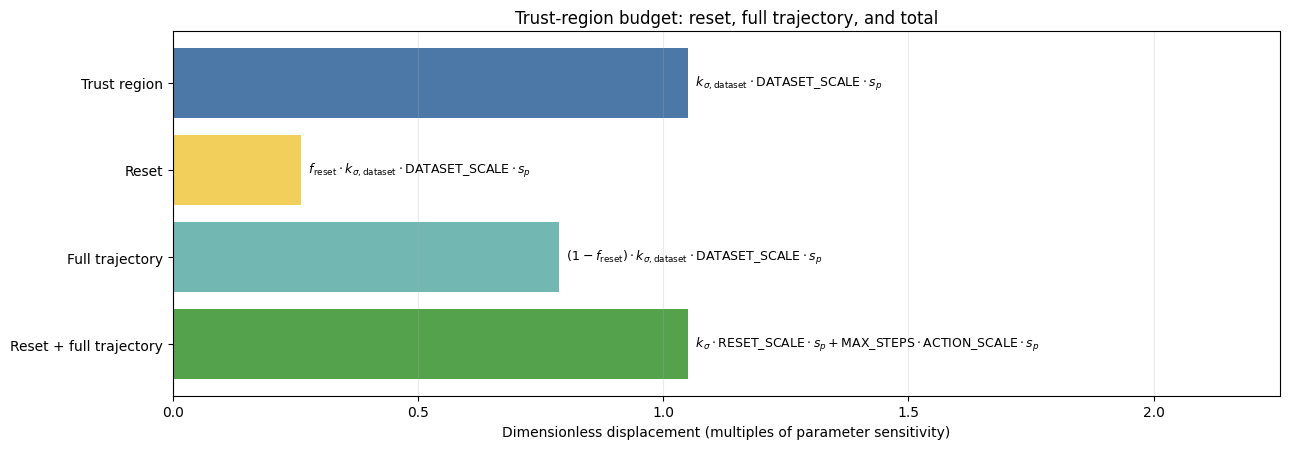

In [3]:
sensitivities = sensitivity_vec()
dataset_std = dataset_std_vec()
reset_std = reset_std_vec()
step_max = action_high.astype(np.float64)
trajectory_max = MAX_STEPS * step_max
k_dataset = DEFAULT_K_SIGMA_DATASET
k_reset = DEFAULT_K_SIGMA
dataset_edge_scale = k_dataset * DATASET_SCALE
reset_excursion_scale = k_reset * RESET_SCALE
trajectory_scale = MAX_STEPS * ACTION_SCALE
combined_scale = reset_excursion_scale + trajectory_scale
assert np.isclose(combined_scale, dataset_edge_scale), 'Scale budget does not match the trust-region radius'

scale_rows = [
    ['Exploration scale', '`EXPLORATION_SCALE`', 'largest tested scale with ≥90% successful TraceWin simulations for both dataset Gaussian and Bayesian Sobol samples', fmt(EXPLORATION_SCALE), 'shared exploration width; `success=True`, therefore runs with `All particles are lost` are excluded from the successful fraction'],
    ['Dataset Gaussian width', '`DATASET_SCALE`', '`DATASET_SCALE = EXPLORATION_SCALE`', fmt(DATASET_SCALE), '`dataset_std_p = DATASET_SCALE × sensitivity_p`'],
    ['Bayesian half-width', '`BAYESIAN_SCALE`', '`BAYESIAN_SCALE = EXPLORATION_SCALE`', fmt(BAYESIAN_SCALE), 'default ± Bayesian interval'],
    ['Reset Gaussian width', '`RESET_SCALE`', '`f_reset × k_sigma_dataset × DATASET_SCALE / k_sigma`', fmt(RESET_SCALE), '`reset_std_p = RESET_SCALE × sensitivity_p`'],
    ['Per-step action half-width', '`ACTION_SCALE`', '`(1 − f_reset) × k_sigma_dataset × DATASET_SCALE / MAX_STEPS`', fmt(ACTION_SCALE), '`step_max_p = ACTION_SCALE × sensitivity_p`'],
    ['Episode horizon', '`MAX_STEPS`', 'configured episode length', str(MAX_STEPS), 'maximum number of actions'],
]
parameter_rows = []
for i, parameter in enumerate(PARAMETERS):
    parameter_rows.append([
        i, f'`{parameter.name}`', fmt(parameter.default), fmt(sensitivities[i]),
        fmt_bound(parameter.hw_min), fmt_bound(parameter.hw_max),
        fmt(dataset_std[i]), fmt(reset_std[i]), f'±{fmt(step_max[i])}', f'±{fmt(trajectory_max[i])}',
    ])

warnings = verify_constraints(
    dataset_scale=DATASET_SCALE, reset_scale=RESET_SCALE,
    action_scale=ACTION_SCALE, max_steps=MAX_STEPS,
)
budget_variable_rows = [
    ['`k_sigma`', fmt(k_reset), 'reset excursion measured in reset standard deviations'],
    ['`RESET_SCALE`', fmt(RESET_SCALE), 'Gaussian reset width in sensitivity units'],
    ['`MAX_STEPS`', str(MAX_STEPS), 'number of actions in a full trajectory'],
    ['`ACTION_SCALE`', fmt(ACTION_SCALE), 'maximum per-step action in sensitivity units'],
    ['`k_sigma_dataset`', fmt(k_dataset), 'dataset trust-region radius in dataset standard deviations'],
    ['`DATASET_SCALE`', fmt(DATASET_SCALE), 'dataset standard deviation in sensitivity units'],
    ['`f_reset`', fmt(DEFAULT_F_RESET), 'fraction of the trust-region radius assigned to reset'],
]
parts = [
    '### 2.4 Current global scales',
    table(['Quantity', 'Symbol', 'Formula', 'Value', 'Physical meaning'], scale_rows),
    '### 2.5 Full 25% / 75% trust-region allocation',
    'Values used in the budget equation:',
    table(['Variable', 'Value', 'Meaning'], budget_variable_rows),
    'Budget identities (all distances are expressed in units of parameter sensitivity):',
    (f'```text\n'
     f'Trust region = k_sigma_dataset × DATASET_SCALE × sensitivity '
     f'= {fmt(k_dataset)} × {fmt(DATASET_SCALE)} × sensitivity '
     f'= {fmt(dataset_edge_scale)} × sensitivity\n\n'
     f'Reset = k_sigma × RESET_SCALE × sensitivity '
     f'= {fmt(k_reset)} × {fmt(RESET_SCALE)} × sensitivity '
     f'= {fmt(reset_excursion_scale)} × sensitivity ({DEFAULT_F_RESET:.0%} of trust region)\n\n'
     f'Full trajectory = MAX_STEPS × ACTION_SCALE × sensitivity '
     f'= {MAX_STEPS} × {fmt(ACTION_SCALE)} × sensitivity '
     f'= {fmt(trajectory_scale)} × sensitivity ({1.0 - DEFAULT_F_RESET:.0%} of trust region)\n\n'
     f'Reset + full trajectory = {fmt(reset_excursion_scale)} × sensitivity + '
     f'{fmt(trajectory_scale)} × sensitivity = {fmt(combined_scale)} × sensitivity '
     f'= Trust region\n```'),
]
if warnings:
    parts += ['Hardware-clipping diagnostics:', '```text\n' + '\n'.join(warnings) + '\n```']
parts += [
    '### 2.6 Per-parameter physical intervals',
    'All intervals come from the sensitivity in the same row. `Trajectory max` is action-only; hardware clipping may reduce the reachable displacement.',
    table(
        ['#', 'Parameter', 'Default', 'Sensitivity', 'HW min', 'HW max', 'Dataset std', 'Reset std', 'Action/step', 'Trajectory max'],
        parameter_rows,
    ),
]
display(Markdown('\n\n'.join(parts)))

labels = ['Trust region', 'Reset', 'Full trajectory', 'Reset + full trajectory']
values = [dataset_edge_scale, reset_excursion_scale, trajectory_scale, combined_scale]
formula_labels = [
    r'$k_{\sigma,\mathrm{dataset}} \cdot \mathrm{DATASET\_SCALE} \cdot s_p$',
    r'$f_{\mathrm{reset}} \cdot k_{\sigma,\mathrm{dataset}} \cdot \mathrm{DATASET\_SCALE} \cdot s_p$',
    r'$(1-f_{\mathrm{reset}}) \cdot k_{\sigma,\mathrm{dataset}} \cdot \mathrm{DATASET\_SCALE} \cdot s_p$',
    r'$k_{\sigma} \cdot \mathrm{RESET\_SCALE} \cdot s_p + \mathrm{MAX\_STEPS} \cdot \mathrm{ACTION\_SCALE} \cdot s_p$',
]
colors = ['#4c78a8', '#f2cf5b', '#72b7b2', '#54a24b']
fig, ax = plt.subplots(figsize=(13, 4.6))
bars = ax.barh(labels, values, color=colors)
for bar, value, formula in zip(bars, values, formula_labels):
    ax.text(value, bar.get_y() + bar.get_height() / 2, '  ' + formula, va='center', fontsize=9)
ax.set_xlim(0, max(values) * 2.15)
ax.set_xlabel('Dimensionless displacement (multiples of parameter sensitivity)')
ax.set_title('Trust-region budget: reset, full trajectory, and total')
ax.grid(axis='x', alpha=0.25)
ax.invert_yaxis()
fig.tight_layout()
plt.show()


### 2.7 Exact per-step action bounds

The preceding sensitivity calibration now justifies the physical bounds. For parameter $p$, the policy may request a delta inside

$$a^{min}_p=-ACTION\_SCALE\,s_p,\qquad a^{max}_p=+ACTION\_SCALE\,s_p.$$

Therefore the complete bound vectors used to construct `Env.action_space` are

$$\mathbf{a}^{min}=-ACTION\_SCALE\,(s_1,\ldots,s_{18}),\qquad \mathbf{a}^{max}=+ACTION\_SCALE\,(s_1,\ldots,s_{18}),$$
$$Env.action\_space=\operatorname{Box}\left(low=\mathbf{a}^{min},high=\mathbf{a}^{max},dtype=float32\right).$$

Thus `ACTION_SCALE` is shared, but the numerical bounds differ across parameters because each has its own $s_p$. This is the precise point at which sensitivity defines the action space.

### 2.8 How the policy chooses a value inside the `Box`

The environment defines the allowed space but does **not** choose the action. At step $t$, the policy receives the current observation $o_t$ and produces all 18 requested deltas jointly:

$$a^{requested}_t\sim\pi_\theta(\cdot\mid o_t)\quad\text{during stochastic training},$$
$$a^{requested}_t=\pi^{det}_\theta(o_t)\quad\text{during deterministic evaluation}.$$

The policy parameters $\theta$ are learned to maximize cumulative reward. Training noise supplies exploration, while deterministic evaluation uses the policy's direct prediction. The result is therefore a learned beam correction, not a fixed perturbation and not a call to `action_space.sample()`.

### 2.9 From requested action to hardware-valid parameters

The environment first clips the requested delta using those action-space bounds:

$$a^{applied}_{t,p}=\operatorname{clip}_{action\ space}\left(a^{requested}_{t,p},-ACTION\_SCALE\,s_p,+ACTION\_SCALE\,s_p\right).$$

It then adds the applied delta to the current physical parameter and clips the candidate value using the explicit hardware bounds:

$$p^{candidate}_{t+1,p}=p_{t,p}+a^{applied}_{t,p},$$
$$p_{t+1,p}=\operatorname{clip}_{hardware}\left(p^{candidate}_{t+1,p},p^{HW,min}_p,p^{HW,max}_p\right).$$

In compact form, the complete update is therefore

$$p_{t+1,p}=\operatorname{clip}_{hardware}\!\left(p_{t,p}+\operatorname{clip}_{action\ space}\!\left(a^{requested}_{t,p},-ACTION\_SCALE\,s_p,+ACTION\_SCALE\,s_p\right),p^{HW,min}_p,p^{HW,max}_p\right).$$

### 2.10 Cumulative trajectory budget

Actions are incremental and cumulative: every applied delta starts from the parameter value reached at the previous step. If all actions for parameter $p$ have maximum magnitude and point in the same direction, the action-only displacement is bounded by

$$|p_{T,p}-p_{0,p}|\le T\,ACTION\_SCALE\,s_p\le MAX\_STEPS\,ACTION\_SCALE\,s_p.$$

Including the calibrated worst-case reset gives a separate theoretical allowance:

$$|p_{T,p}-p^{default}_p|\lesssim(k_{reset}RESET\_SCALE+MAX\_STEPS\,ACTION\_SCALE)s_p.$$

This is a reachability bound, not a command imposed on the policy: actions may be smaller, reverse direction, or be zero. Hardware clipping can only reduce the displacement. A successful episode is truncated after `MAX_STEPS`; a failed simulation terminates it immediately.

## 3. Episode initialization (reset)

### 3.1 Reset distribution

At reset, every parameter starts from its default plus independent Gaussian noise. The candidate value is then clipped explicitly between that parameter's hardware bounds:

$$\epsilon_p\sim\mathcal{N}\left(0,(RESET\_SCALE\,s_p)^2\right),$$
$$p^{candidate}_{0,p}=p^{default}_p+\epsilon_p,$$
$$p_{0,p}=\operatorname{clip}_{hardware}\left(p^{candidate}_{0,p},p^{HW,min}_p,p^{HW,max}_p\right).$$

`reset(options={"randomize_params": False})` disables this perturbation. The simulator context is then reset: the surrogate samples an input beam and an ensemble member, while TraceWin prepares its real execution context.

### 3.2 Why reset has its own scale

Reset randomization exposes the policy to different initial machine configurations rather than always starting at the default. Its calibrated worst-case allocation occupies 25% of the dataset trust-region radius, leaving 75% for corrective motion during the episode. Hardware clipping remains the final validity constraint.


In [4]:
w, ref = SCORE_WEIGHTS, SCORE_REFERENCES
score_formula = f"""```text
score = {fmt(w['npart_ratio'])} * clip(npart_ratio, 0, 1)
        - {fmt(w['emittance'])} * ((ex - {fmt(ref['ex'])}) + (ey - {fmt(ref['ey'])}))
        - {fmt(w['offset'])} * ((abs(x0) - {fmt(ref['x0'])}) + (abs(y0) - {fmt(ref['y0'])}))
        - {fmt(w['angle'])} * ((abs(x'0) - {fmt(ref["x'0"])}) + (abs(y'0) - {fmt(ref["y'0"])}))
        - {fmt(w['size'])} * ((SizeX - {fmt(ref['SizeX'])}) + (SizeY - {fmt(ref['SizeY'])}))
```"""
score_rows = [
    ['Transmission', '`npart_ratio`', 'maximize', fmt(w['npart_ratio']), 'clipped to [0, 1]'],
    ['Emittance', '`ex`, `ey`', 'reference-relative', fmt(w['emittance']), f"{fmt(ref['ex'])}, {fmt(ref['ey'])}"],
    ['Centroid offset', '`abs(x0)`, `abs(y0)`', 'minimize magnitude', fmt(w['offset']), f"{fmt(ref['x0'])}, {fmt(ref['y0'])}"],
    ['Angular offset', "`abs(x'0)`, `abs(y'0)`", 'minimize magnitude', fmt(w['angle']), fmt(ref["x'0"]) + ', ' + fmt(ref["y'0"])],
    ['RMS size', '`SizeX`, `SizeY`', 'reference-relative', fmt(w['size']), f"{fmt(ref['SizeX'])}, {fmt(ref['SizeY'])}"],
]
reward_formula = f"""```text
if simulation succeeds:
    reward_t = score_t - score_(t-1)
    terminated = False
    truncated = (step == {MAX_STEPS})
else:
    score_t = {fmt(ERROR_SCORE)}       # reporting sentinel
    reward_t = -{fmt(FAILURE_PENALTY)} # bounded training penalty
    terminated = True
    truncated = False
```"""
display(Markdown('\n\n'.join([
    '## 4. Score, reward, and termination',
    'The score is computed from the **final beam stage** and higher is better. This formula is generated from the current configuration:',
    score_formula,
    table(['Component', 'Features', 'Intent', 'Weight', 'Reference'], score_rows),
    (f'A beam at the references with full transmission scores **{fmt(w["npart_ratio"])}**. '
     'Values better than a reference can receive a linear bonus; the score is not capped above.'),
    '### 4.1 Reward and episode ending',
    reward_formula,
    (f'`ERROR_SCORE={fmt(ERROR_SCORE)}` is a bookkeeping sentinel, not a physical score, and is not used in the reward difference. '
     f'Failures instead receive `-{fmt(FAILURE_PENALTY)}` and terminate the episode. '
     '`best_score` and `best_params` retain the highest score reached in the episode.'),
])))


## 4. Score, reward, and termination

The score is computed from the **final beam stage** and higher is better. This formula is generated from the current configuration:

```text
score = 100 * clip(npart_ratio, 0, 1)
        - 200 * ((ex - 0.05) + (ey - 0.05))
        - 1 * ((abs(x0) - 0) + (abs(y0) - 0))
        - 1 * ((abs(x'0) - 0) + (abs(y'0) - 0))
        - 1 * ((SizeX - 5) + (SizeY - 5))
```

| Component | Features | Intent | Weight | Reference |
| --- | --- | --- | --- | --- |
| Transmission | `npart_ratio` | maximize | 100 | clipped to [0, 1] |
| Emittance | `ex`, `ey` | reference-relative | 200 | 0.05, 0.05 |
| Centroid offset | `abs(x0)`, `abs(y0)` | minimize magnitude | 1 | 0, 0 |
| Angular offset | `abs(x'0)`, `abs(y'0)` | minimize magnitude | 1 | 0, 0 |
| RMS size | `SizeX`, `SizeY` | reference-relative | 1 | 5, 5 |

A beam at the references with full transmission scores **100**. Values better than a reference can receive a linear bonus; the score is not capped above.

### 4.1 Reward and episode ending

```text
if simulation succeeds:
    reward_t = score_t - score_(t-1)
    terminated = False
    truncated = (step == 20)
else:
    score_t = -999       # reporting sentinel
    reward_t = -10 # bounded training penalty
    terminated = True
    truncated = False
```

`ERROR_SCORE=-999` is a bookkeeping sentinel, not a physical score, and is not used in the reward difference. Failures instead receive `-10` and terminate the episode. `best_score` and `best_params` retain the highest score reached in the episode.

## 5. Simulator backends and diagnostics

| Choice | `TraceWinEnv` | `SurrogateEnv` |
| --- | --- | --- |
| Propagation | TraceWin physics simulator | Trained `ModularMLP` ensemble |
| Speed | Slow | Fast |
| Physical failures | Detects TraceWin particle-loss errors | Does not currently classify particle-loss regions |
| Reset context | TraceWin input and execution context | Samples a dataset `beam0` and an ensemble member |
| Gym behavior | Shared `BaseBeamEnv` | Shared `BaseBeamEnv` |

The surrogate predicts continuous beam states and normally reports `success=True` whenever inference succeeds. Failed TraceWin simulations are not beam-state training targets, so parameters that lose all particles in TraceWin may still receive a plausible surrogate prediction. This limitation is not an action-space safety guarantee.

### 5.1 Render-only diagnostics

`render()` shows parameter trajectories, observed beam features, score/reward, and parameter KNN distance from the reference dataset. KNN distance is a coverage diagnostic: it is **not** part of the observation, score, reward, termination rule, or action clipping. Rendering is lazy and does not affect training steps.



